In [1]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt

sys.path.append(os.path.dirname(os.path.dirname(os.path.abspath("__file__"))) + "/src")

from ring_attractor.network import RingAttractor, CosineKernelInitStrategy, RingAttractorSimulator
from ring_attractor.nonlinearity import ReLUNonlinearity
from ring_attractor.spiking import SpikeGenerator, SpikeGeneratorSimulator, SpikeProcessor

In [2]:
NETWORK_SIZE = 100
J0, J1 = -2.0, 4.0 # We might want to tweak this

SIMULATION_TIMESTEP = 0.01 # Might want to change this to 0.1?
TAU = 100.0
SIGMA = 0.1 # Noise

CUE_THETA_TARGET = np.pi / 2
CUE_AMPLITUDE = 2.0

T_CUE = 200   # steps with cue on  (bump formation)
T_FREE = 800  # steps with cue off (free diffusion)
T_TOTAL = T_CUE + T_FREE

# The rate scale multiplies the dimensionless attractor rates before Poisson sampling.
# Increase if the raster looks too sparse, decrease if fraction-2+ is large.
# Target -- most bins 0 or 1, peak neurons firing ~10-30% of steps.
RATE_SCALE = 100.0
BIN_FACTOR = 100 # 1ms (100 * SIMULATION_TIMESTEP)

SEED = 42

In [3]:
rng = np.random.default_rng(SEED)

attractor = RingAttractor(
    NETWORK_SIZE,
    CosineKernelInitStrategy(j0=J0, j1=J1),
    ReLUNonlinearity(),
    rng,
)

simulator = RingAttractorSimulator(
    attractor,
    SIMULATION_TIMESTEP,
    tau=TAU,
    sigma=SIGMA,
    rng=rng,
)

# rate_scale lives on SpikeGenerator so SpikeGeneratorSimulator doesn't need to know about it.
spike_gen = SpikeGenerator(dt=SIMULATION_TIMESTEP, rate_scale=RATE_SCALE, rng=rng)

sgs = SpikeGeneratorSimulator(spike_gen, simulator)

In [4]:
# Build the cue schedule (first cue then no cue to see diffusion)
cue_on = CUE_AMPLITUDE * np.cos(attractor.neuron_angles - CUE_THETA_TARGET)
cue_schedule = np.zeros((T_TOTAL, NETWORK_SIZE))
cue_schedule[:T_CUE] = cue_on

sgs.perform_steps(cue_schedule)

spikes_int = sgs.spikes
rates_true = sgs.neuron_rates
theta_hat  = sgs.decoded_angle
confidence = sgs.decoding_confidence

print(f"spikes_int : {spikes_int.shape}, dtype={spikes_int.dtype}")
print(f"rates_true : {rates_true.shape}, dtype={rates_true.dtype}")

spikes_int : (1000, 100), dtype=int32
rates_true : (1000, 100), dtype=float32


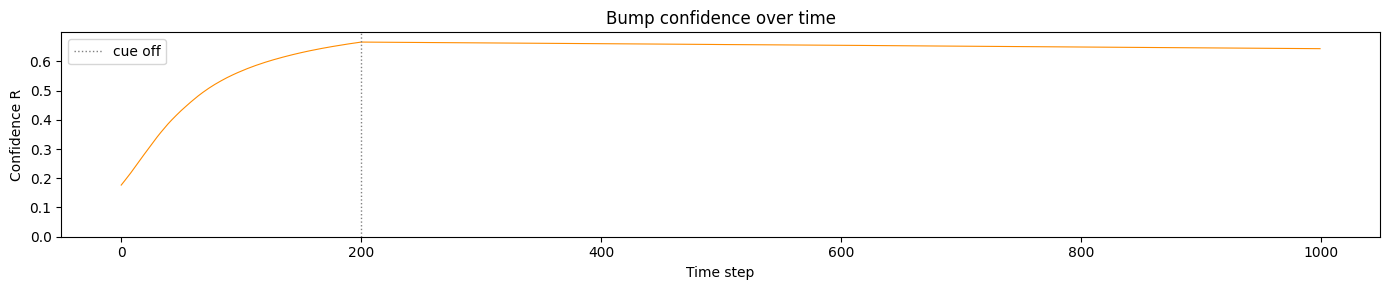

In [5]:
fig, ax = plt.subplots(figsize=(14, 3))

ax.plot(confidence, color="darkorange", lw=0.8)
ax.axvline(T_CUE, color="gray", linestyle=":", lw=1, label="cue off")
ax.axhline(0, color="k", lw=0.5)

ax.set_xlabel("Time step")
ax.set_ylabel("Confidence R")
ax.set_title("Bump confidence over time")
ax.set_ylim(0, None)
ax.legend()
plt.tight_layout()
plt.show()

In [6]:
# Sanity check - spike count distribution - most bins should be 0 or 1.

neuron_peak = np.argmin(np.abs(attractor.neuron_angles - CUE_THETA_TARGET))
neuron_back = np.argmin(np.abs(attractor.neuron_angles - (CUE_THETA_TARGET + np.pi)))

print("Overall distribution")
print(f"  0s  : {(spikes_int == 0).mean():.3f}")
print(f"  1s  : {(spikes_int == 1).mean():.3f}")
print(f"  2+  : {(spikes_int >= 2).mean():.3f}")
print(f"  max : {spikes_int.max()}")
print()
print(f"Mean spikes/step — peak neuron ({neuron_peak}): {spikes_int[:, neuron_peak].mean():.4f}")
print(f"Mean spikes/step — background  ({neuron_back}): {spikes_int[:, neuron_back].mean():.4f}")

Overall distribution
  0s  : 0.987
  1s  : 0.013
  2+  : 0.000
  max : 2

Mean spikes/step — peak neuron (25): 0.0300
Mean spikes/step — background  (75): 0.0060


In [ ]:
# ── Sanity check 2: raster plot ───────────────────────────────────────────────
# Neurons are already ordered by preferred angle, so a horizontal stripe
# around neuron_peak during the cue phase is a good sign.
# After cue-off the stripe should slowly drift (bump diffusion).

fig, ax = plt.subplots(figsize=(14, 5))

locs = np.argwhere(spikes_int > 0)   # (K, 2): [:, 0]=time, [:, 1]=neuron
ax.scatter(locs[:, 0], locs[:, 1], s=0.3, c="k", alpha=0.4, linewidths=0)
ax.axvline(T_CUE, color="red", lw=1.5, linestyle="--", label="cue off")

ax.set_xlabel("Time step")
ax.set_ylabel("Neuron (sorted by preferred angle)")
ax.set_title("Spike raster — cue phase → free diffusion")
ax.set_ylim(-1, NETWORK_SIZE)
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# ── Sanity check 3: mean firing rate per neuron ───────────────────────────────
# Should be highest near CUE_THETA_TARGET and low on the opposite side.

mean_rate = spikes_int.mean(axis=0)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(np.degrees(attractor.neuron_angles), mean_rate, width=360 / NETWORK_SIZE)
ax.axvline(np.degrees(CUE_THETA_TARGET), color="red", linestyle="--", lw=1.5, label="θ target")
ax.set_xlabel("Preferred angle (degrees)")
ax.set_ylabel("Mean spikes per step")
ax.set_title("Mean firing rate by preferred angle")
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# ── Sanity check 4: decoded θ and confidence over time ───────────────────────
# θ̂ should lock onto CUE_THETA_TARGET during the cue phase, then slowly drift.
# Confidence R should rise during cue and plateau, then hold (or drop slowly).

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 5), sharex=True)
steps = np.arange(T_TOTAL)

ax1.plot(steps, np.degrees(theta_hat), color="steelblue", lw=0.8)
ax1.axhline(np.degrees(CUE_THETA_TARGET), color="red", linestyle="--", lw=1, label="target θ")
ax1.axvline(T_CUE, color="gray", linestyle=":", lw=1)
ax1.set_ylabel("θ̂ (degrees)")
ax1.legend()

ax2.plot(steps, confidence, color="darkorange", lw=0.8)
ax2.axvline(T_CUE, color="gray", linestyle=":", lw=1, label="cue off")
ax2.set_ylabel("Confidence R")
ax2.set_xlabel("Step")
ax2.set_ylim(0, None)
ax2.legend()

plt.suptitle("Bump decoding: cue phase → free diffusion")
plt.tight_layout()
plt.show()

In [ ]:
# ── Bin spikes and smooth ─────────────────────────────────────────────────────
WINDOW_BINS = 3  # causal smoothing window in bins

processor  = SpikeProcessor(dt=SIMULATION_TIMESTEP, bin_factor=BIN_FACTOR)
spikes_bin = processor.bin_spikes(spikes_int)   # (T//BIN_FACTOR, NETWORK_SIZE)

dt_bin = SIMULATION_TIMESTEP * BIN_FACTOR
T_BIN  = spikes_bin.shape[0]


def smooth_causal_boxcar(signal: np.ndarray, window: int) -> np.ndarray:
    """Causal boxcar smoothing along axis 0.  output[t] = mean(input[t-w+1 : t+1])."""
    kernel = np.ones(window) / window
    return np.apply_along_axis(
        lambda col: np.convolve(col, kernel, mode="full")[: len(col)],
        axis=0,
        arr=signal.astype(float),
    )


# Divide by dt_bin to express rates per unit time (comparable to rates_true * RATE_SCALE)
rates_smooth = smooth_causal_boxcar(spikes_bin, WINDOW_BINS) / dt_bin

# Average ground-truth rates over each bin for a fair comparison
rates_true_bin = rates_true[: T_BIN * BIN_FACTOR].reshape(T_BIN, BIN_FACTOR, NETWORK_SIZE).mean(axis=1)

print(f"spikes_int    : {spikes_int.shape}")
print(f"spikes_bin    : {spikes_bin.shape}   (BIN_FACTOR={BIN_FACTOR})")
print(f"rates_smooth  : {rates_smooth.shape}")
print(f"rates_true_bin: {rates_true_bin.shape}")

In [ ]:
# ── Sanity check 5: smoothed rates vs ground-truth rates ─────────────────────
# Select three neurons: bump peak, 45° off, 90° off.
# The orange (smoothed spikes) should track the blue (true rates), up to noise.

neuron_peak = np.argmin(np.abs(attractor.neuron_angles - CUE_THETA_TARGET))
neuron_mid  = np.argmin(np.abs(attractor.neuron_angles - (CUE_THETA_TARGET + np.pi / 4)))
neuron_far  = np.argmin(np.abs(attractor.neuron_angles - (CUE_THETA_TARGET + np.pi / 2)))

bin_steps = np.arange(T_BIN)

fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)
for ax, n, label in zip(
    axes,
    [neuron_peak, neuron_mid, neuron_far],
    ["peak (0°)", "+45°", "+90°"],
):
    ax.plot(bin_steps, rates_true_bin[:, n] * RATE_SCALE, color="steelblue",
            alpha=0.8, lw=1.2, label="true rate")
    ax.plot(bin_steps, rates_smooth[:, n], color="darkorange",
            alpha=0.8, lw=1.2, label="smoothed spikes")
    ax.axvline(T_CUE // BIN_FACTOR, color="gray", linestyle=":", lw=1)
    ax.set_ylabel(f"neuron {n}\n({label})", fontsize=9)
    ax.legend(loc="upper right", fontsize=8)

axes[-1].set_xlabel("Bin index")
plt.suptitle("Smoothed spike rates vs ground-truth rates")
plt.tight_layout()
plt.show()

In [ ]:
# ── Build teacher dataset ─────────────────────────────────────────────────────
# theta_hat_bin: one angle per bin, taken at the start of each bin.
theta_hat_bin = theta_hat[: T_BIN * BIN_FACTOR : BIN_FACTOR]

dataset = {
    # ── Arrays ────────────────────────────────────────────────────
    "spikes_int":    spikes_int,    # (T, N)     — raw Poisson counts
    "spikes_bin":    spikes_bin,    # (T_bin, N) — binned integer counts
    "rates_smooth":  rates_smooth,  # (T_bin, N) — smoothed estimated rates
    "rates_true":    rates_true,    # (T, N)     — ground-truth rates (teacher-internal)
    "theta_hat":     theta_hat,     # (T,)       — decoded angle at integration res.
    "theta_hat_bin": theta_hat_bin, # (T_bin,)   — decoded angle at bin resolution
    # ── Metadata ──────────────────────────────────────────────────
    "params": {
        "N":                     NETWORK_SIZE,
        "J0":                    J0,
        "J1":                    J1,
        "dt_int":                SIMULATION_TIMESTEP,
        "dt_bin":                dt_bin,
        "bin_factor":            BIN_FACTOR,
        "smoothing_window_bins": WINDOW_BINS,
        "tau":                   TAU,
        "sigma":                 SIGMA,
        "rate_scale":            RATE_SCALE,
        "T_cue":                 T_CUE,
        "T_free":                T_FREE,
        "theta_target":          float(CUE_THETA_TARGET),
        "cue_amplitude":         CUE_AMPLITUDE,
        "seed":                  SEED,
    },
}

print("Teacher dataset summary")
print("=" * 45)
for k, v in dataset.items():
    if isinstance(v, np.ndarray):
        print(f"  {k:20s}: shape={str(v.shape):15s} dtype={v.dtype}")
    elif isinstance(v, dict):
        print(f"  {'params':20s}: {v}")